
# Regressão OLS com Variável Categórica

Este notebook apresenta um exemplo didático de **regressão linear OLS com variável explicativa qualitativa/categórica**.

A ideia principal é mostrar:

1. Por que **não devemos transformar categorias diretamente em números** e usar como se fossem variáveis quantitativas.
2. Como aplicar **One-Hot Encoding / variáveis dummy**.
3. Como interpretar o **intercepto** e os **coeficientes das dummies**.
4. Como calcular os valores previstos para cada categoria.

Neste exemplo, vamos analisar o **gasto médio de clientes** conforme o tipo de refeição:

- Café
- Almoço
- Jantar


In [1]:

# ============================================================
# IMPORTAÇÃO DOS PACOTES
# ============================================================

import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Configuração visual básica dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.size"] = 12



## 1. Criação do dataset de exemplo

Neste exemplo, a variável resposta será:

\[
Y = \text{gasto do cliente}
\]

A variável explicativa categórica será:

\[
X = \text{tipo de refeição}
\]

A variável `refeicao` possui três categorias:

- `Cafe`
- `Almoco`
- `Jantar`

Como ela é qualitativa, não devemos tratá-la diretamente como número.


In [2]:

# ============================================================
# CRIAÇÃO DO DATASET
# ============================================================

df_refeicoes = pd.DataFrame({
    "cliente": [
        "Cliente_01", "Cliente_02", "Cliente_03",
        "Cliente_04", "Cliente_05", "Cliente_06",
        "Cliente_07", "Cliente_08", "Cliente_09"
    ],
    "refeicao": [
        "Cafe", "Cafe", "Cafe",
        "Almoco", "Almoco", "Almoco",
        "Jantar", "Jantar", "Jantar"
    ],
    "gasto": [
        18, 22, 20,
        34, 36, 35,
        48, 52, 50
    ]
})

df_refeicoes


,cliente,refeicao,gasto
0,Cliente_01,Cafe,18
1,Cliente_02,Cafe,22
2,Cliente_03,Cafe,20
3,Cliente_04,Almoco,34
4,Cliente_05,Almoco,36
5,Cliente_06,Almoco,35
6,Cliente_07,Jantar,48
7,Cliente_08,Jantar,52
8,Cliente_09,Jantar,50



## 2. Análise inicial da base

Antes de ajustar qualquer modelo, é importante conhecer a estrutura da base:

- quantidade de observações;
- tipo das variáveis;
- estatísticas descritivas;
- médias por categoria.


In [3]:

# Informações gerais do dataset
df_refeicoes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   cliente   9 non-null      object
 1   refeicao  9 non-null      object
 2   gasto     9 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 344.0+ bytes


In [4]:

# Estatísticas descritivas da variável numérica
df_refeicoes.describe()


,gasto
count,9.000000
mean,35.000000
std,13.076697
min,18.000000
25%,22.000000
50%,35.000000
75%,48.000000
max,52.000000


In [5]:

# Estatísticas da variável resposta por tipo de refeição
df_refeicoes.groupby("refeicao")["gasto"].describe()


,count,mean,std,min,25%,50%,75%,max
refeicao,,,,,,,,
Almoco,3.0,35.0,1.0,34.0,34.5,35.0,35.5,36.0
Cafe,3.0,20.0,2.0,18.0,19.0,20.0,21.0,22.0
Jantar,3.0,50.0,2.0,48.0,49.0,50.0,51.0,52.0


In [6]:

# Média do gasto por categoria
df_refeicoes.groupby("refeicao")["gasto"].mean()


refeicao
Almoco    35.0
Cafe      20.0
Jantar    50.0
Name: gasto, dtype: float64


## 3. Tabela de frequências da variável categórica

A tabela de frequências ajuda a verificar quantas observações existem em cada categoria.

Neste exemplo, temos a mesma quantidade de observações para cada tipo de refeição.


In [7]:

# Contagem absoluta
contagem = df_refeicoes["refeicao"].value_counts(dropna=False)

# Percentual
percentual = df_refeicoes["refeicao"].value_counts(
    dropna=False,
    normalize=True
)

# Tabela final de frequências
tabela_freq = pd.concat(
    [contagem, percentual],
    axis=1,
    keys=["contagem", "%"]
)

tabela_freq


,contagem,%
refeicao,,
Cafe,3,0.333333
Almoco,3,0.333333
Jantar,3,0.333333



# 4. Erro comum: transformar categoria em número

Uma prática incorreta é converter categorias em códigos numéricos e usar esses códigos diretamente na regressão.

Por exemplo:

- `Almoco = 1`
- `Cafe = 2`
- `Jantar = 3`

O problema é que esses números são apenas **rótulos codificados**. Eles não representam uma escala real.

Ou seja:

\[
Almoco \neq 1
\]

\[
Cafe \neq 2
\]

\[
Jantar \neq 3
\]

Ao usar esses códigos como variável quantitativa, o modelo passa a assumir uma relação linear artificial entre as categorias. Esse problema é chamado aqui de **ponderação arbitrária**.


In [8]:

# ============================================================
# CODIFICAÇÃO NUMÉRICA DA CATEGORIA
# ============================================================
# Esta etapa é feita apenas para demonstrar o erro conceitual.

df_refeicoes["refeicao_numerica"] = LabelEncoder().fit_transform(df_refeicoes["refeicao"])
df_refeicoes["refeicao_numerica"] = df_refeicoes["refeicao_numerica"] + 1

df_refeicoes


,cliente,refeicao,gasto,refeicao_numerica
0,Cliente_01,Cafe,18,2
1,Cliente_02,Cafe,22,2
2,Cliente_03,Cafe,20,2
3,Cliente_04,Almoco,34,1
4,Cliente_05,Almoco,36,1
5,Cliente_06,Almoco,35,1
6,Cliente_07,Jantar,48,3
7,Cliente_08,Jantar,52,3
8,Cliente_09,Jantar,50,3


In [9]:

# Verificando o mapeamento criado automaticamente
df_refeicoes[["refeicao", "refeicao_numerica"]].drop_duplicates().sort_values("refeicao_numerica")


,refeicao,refeicao_numerica
3,Almoco,1
0,Cafe,2
6,Jantar,3



## 5. Modelo incorreto com variável categórica transformada em número

Agora vamos ajustar um modelo incorreto:

\[
Gasto = \alpha + \beta \cdot RefeicaoNumerica + \varepsilon
\]

Esse modelo é problemático porque interpreta `refeicao_numerica` como se fosse uma variável quantitativa.

A ordem e a distância entre os códigos foram criadas artificialmente.


In [10]:

# ============================================================
# MODELO INCORRETO
# ============================================================

modelo_refeicao_errado = smf.ols(
    formula="gasto ~ refeicao_numerica",
    data=df_refeicoes
).fit()

modelo_refeicao_errado.summary()


C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  gasto   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     2.293
Date:                Thu, 28 May 2026   Prob (F-statistic):              0.174
Time:                        11:26:51   Log-Likelihood:                -34.103
No. Observations:                   9   AIC:                             72.21
Df Residuals:                       7   BIC:                             72.60
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            20.0000     10.700      1.869      0.104      -5.303      45.303
refeicao_numerica     7.5000      4.953      1.514      0.174      -4.213      19.213
==============================================================================
Omnibus:                        3.317   Durbin-Watson:                   0.496
Prob(Omnibus):                  0.190   Jarque-Bera (JB):                1.505
Skew:                          -0.701   Prob(JB):                        0.471
Kurtosis:                       1.569   Cond. No.                         6.79
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


## 6. Visualização do problema

O gráfico abaixo força uma reta entre categorias.

Isso pode induzir uma interpretação incorreta, como se existisse uma escala contínua entre Café, Almoço e Jantar.

Mas uma variável categórica não possui, necessariamente, distância numérica entre suas categorias.


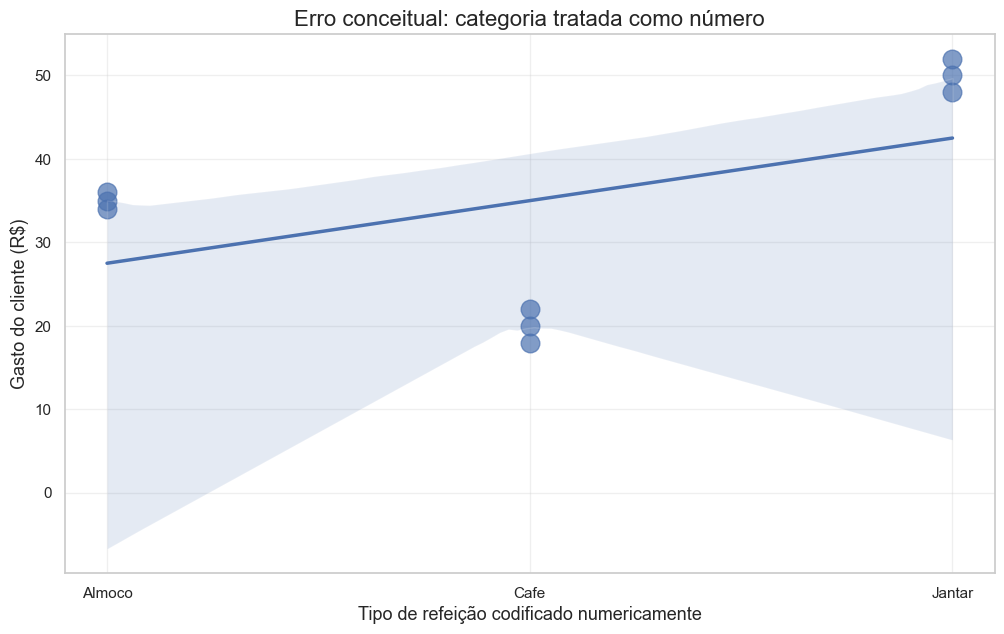

In [11]:

# ============================================================
# GRÁFICO DO MODELO INCORRETO
# ============================================================

plt.figure(figsize=(12, 7))

sns.regplot(
    data=df_refeicoes,
    x="refeicao_numerica",
    y="gasto",
    scatter_kws={"s": 180, "alpha": 0.7},
    line_kws={"linewidth": 2.5}
)

plt.title("Erro conceitual: categoria tratada como número", fontsize=16)
plt.xlabel("Tipo de refeição codificado numericamente", fontsize=13)
plt.ylabel("Gasto do cliente (R$)", fontsize=13)

# Ajustando rótulos do eixo X
mapeamento = (
    df_refeicoes[["refeicao", "refeicao_numerica"]]
    .drop_duplicates()
    .sort_values("refeicao_numerica")
)

plt.xticks(
    ticks=mapeamento["refeicao_numerica"],
    labels=mapeamento["refeicao"]
)

plt.grid(alpha=0.3)
plt.show()



# 7. Forma correta: One-Hot Encoding / variáveis dummy

A forma adequada de usar uma variável categórica em uma regressão OLS é criar variáveis dummy.

Como temos 3 categorias:

\[
k = 3
\]

E o modelo possui intercepto, usamos:

\[
k - 1 = 2
\]

dummies.

Uma categoria será a **referência**. Neste notebook, vamos definir:

\[
Cafe = \text{categoria de referência}
\]

Assim:

| Categoria | D_Almoco | D_Jantar |
|---|---:|---:|
| Cafe | 0 | 0 |
| Almoco | 1 | 0 |
| Jantar | 0 | 1 |


In [12]:

# ============================================================
# DEFININDO A ORDEM DAS CATEGORIAS
# ============================================================
# A primeira categoria será a referência quando usarmos drop_first=True.

df_refeicoes["refeicao"] = pd.Categorical(
    df_refeicoes["refeicao"],
    categories=["Cafe", "Almoco", "Jantar"],
    ordered=False
)

# Criando as dummies
df_refeicoes_dummies = pd.get_dummies(
    df_refeicoes,
    columns=["refeicao"],
    dtype=int,
    drop_first=True
)

df_refeicoes_dummies


,cliente,gasto,refeicao_numerica,refeicao_Almoco,refeicao_Jantar
0,Cliente_01,18,2,0,0
1,Cliente_02,22,2,0,0
2,Cliente_03,20,2,0,0
3,Cliente_04,34,1,1,0
4,Cliente_05,36,1,1,0
5,Cliente_06,35,1,1,0
6,Cliente_07,48,3,0,1
7,Cliente_08,52,3,0,1
8,Cliente_09,50,3,0,1



Observe que foram criadas duas colunas:

- `refeicao_Almoco`
- `refeicao_Jantar`

A categoria `Cafe` não aparece como coluna porque ela é a categoria de referência.

Quando:

\[
D_{Almoco} = 0
\]

e

\[
D_{Jantar} = 0
\]

a observação pertence ao grupo `Cafe`.


In [13]:

# Conferindo as combinações das dummies
df_refeicoes_dummies[
    ["cliente", "gasto", "refeicao_Almoco", "refeicao_Jantar"]
]


,cliente,gasto,refeicao_Almoco,refeicao_Jantar
0,Cliente_01,18,0,0
1,Cliente_02,22,0,0
2,Cliente_03,20,0,0
3,Cliente_04,34,1,0
4,Cliente_05,36,1,0
5,Cliente_06,35,1,0
6,Cliente_07,48,0,1
7,Cliente_08,52,0,1
8,Cliente_09,50,0,1



## 8. Modelo OLS com variáveis dummy

Agora o modelo correto é:

\[
Gasto = \alpha + \beta_1D_{Almoco} + \beta_2D_{Jantar} + \varepsilon
\]

Onde:

- \(\alpha\) representa a média de `gasto` na categoria de referência, `Cafe`;
- \(\beta_1\) representa a diferença média entre `Almoco` e `Cafe`;
- \(\beta_2\) representa a diferença média entre `Jantar` e `Cafe`.


In [14]:

# ============================================================
# MODELO CORRETO COM DUMMIES
# ============================================================

modelo_refeicao_dummies = smf.ols(
    formula="gasto ~ refeicao_Almoco + refeicao_Jantar",
    data=df_refeicoes_dummies
).fit()

modelo_refeicao_dummies.summary()


C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  gasto   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     225.0
Date:                Thu, 28 May 2026   Prob (F-statistic):           2.28e-06
Time:                        11:26:52   Log-Likelihood:                -15.890
No. Observations:                   9   AIC:                             37.78
Df Residuals:                       6   BIC:                             38.37
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          20.0000      1.000     20.000      0.000      17.553      22.447
refeicao_Almoco    15.0000      1.414     10.607      0.000      11.540      18.460
refeicao_Jantar    30.0000      1.414     21.213      0.000      26.540      33.460
==============================================================================
Omnibus:                        0.603   Durbin-Watson:                   2.778
Prob(Omnibus):                  0.740   Jarque-Bera (JB):                0.510
Skew:                           0.000   Prob(JB):                        0.775
Kurtosis:                       1.833   Cond. No.                         3.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


## 9. Interpretação esperada dos coeficientes

Pelos dados do exemplo:

- Média do Café = 20
- Média do Almoço = 35
- Média do Jantar = 50

Logo, o modelo esperado é:

\[
Gasto = 20 + 15D_{Almoco} + 30D_{Jantar}
\]

### Intercepto

\[
\alpha = 20
\]

O intercepto é a média do gasto na categoria de referência:

\[
\alpha = \text{média do Café}
\]

### Dummy de Almoço

\[
\beta_1 = 35 - 20 = 15
\]

O coeficiente da dummy `Almoco` mostra que o gasto médio no Almoço é R$ 15 maior que no Café.

### Dummy de Jantar

\[
\beta_2 = 50 - 20 = 30
\]

O coeficiente da dummy `Jantar` mostra que o gasto médio no Jantar é R$ 30 maior que no Café.


In [15]:

# Parâmetros estimados pelo modelo
modelo_refeicao_dummies.params


Intercept          20.0
refeicao_Almoco    15.0
refeicao_Jantar    30.0
dtype: float64


## 10. Valores ajustados pelo modelo

Os valores ajustados, ou `fitted values`, representam a média estimada para cada grupo.

Como estamos usando apenas uma variável categórica, o modelo prevê a média de cada categoria.


In [16]:

# Salvando os valores ajustados no dataset
df_refeicoes_dummies["fitted"] = modelo_refeicao_dummies.fittedvalues

df_refeicoes_dummies[
    ["cliente", "gasto", "refeicao_Almoco", "refeicao_Jantar", "fitted"]
]


,cliente,gasto,refeicao_Almoco,refeicao_Jantar,fitted
0,Cliente_01,18,0,0,20.0
1,Cliente_02,22,0,0,20.0
2,Cliente_03,20,0,0,20.0
3,Cliente_04,34,1,0,35.0
4,Cliente_05,36,1,0,35.0
5,Cliente_06,35,1,0,35.0
6,Cliente_07,48,0,1,50.0
7,Cliente_08,52,0,1,50.0
8,Cliente_09,50,0,1,50.0



## 11. Cálculo manual das previsões

### Para Café

Como Café é a referência:

\[
D_{Almoco}=0
\]

\[
D_{Jantar}=0
\]

\[
Gasto = 20 + 15 \cdot 0 + 30 \cdot 0 = 20
\]

### Para Almoço

\[
D_{Almoco}=1
\]

\[
D_{Jantar}=0
\]

\[
Gasto = 20 + 15 \cdot 1 + 30 \cdot 0 = 35
\]

### Para Jantar

\[
D_{Almoco}=0
\]

\[
D_{Jantar}=1
\]

\[
Gasto = 20 + 15 \cdot 0 + 30 \cdot 1 = 50
\]


In [17]:

# Conferindo médias observadas versus valores ajustados
comparacao = (
    df_refeicoes_dummies
    .assign(refeicao_original=df_refeicoes["refeicao"].astype(str))
    .groupby("refeicao_original")
    .agg(
        media_observada=("gasto", "mean"),
        media_ajustada=("fitted", "mean")
    )
)

comparacao


,media_observada,media_ajustada
refeicao_original,,
Almoco,35.0,35.0
Cafe,20.0,20.0
Jantar,50.0,50.0



## 12. Gráfico do modelo correto com dummies

Agora o gráfico não deve ser interpretado como uma reta contínua entre categorias.

O objetivo é mostrar que cada categoria possui um valor médio estimado pelo modelo.


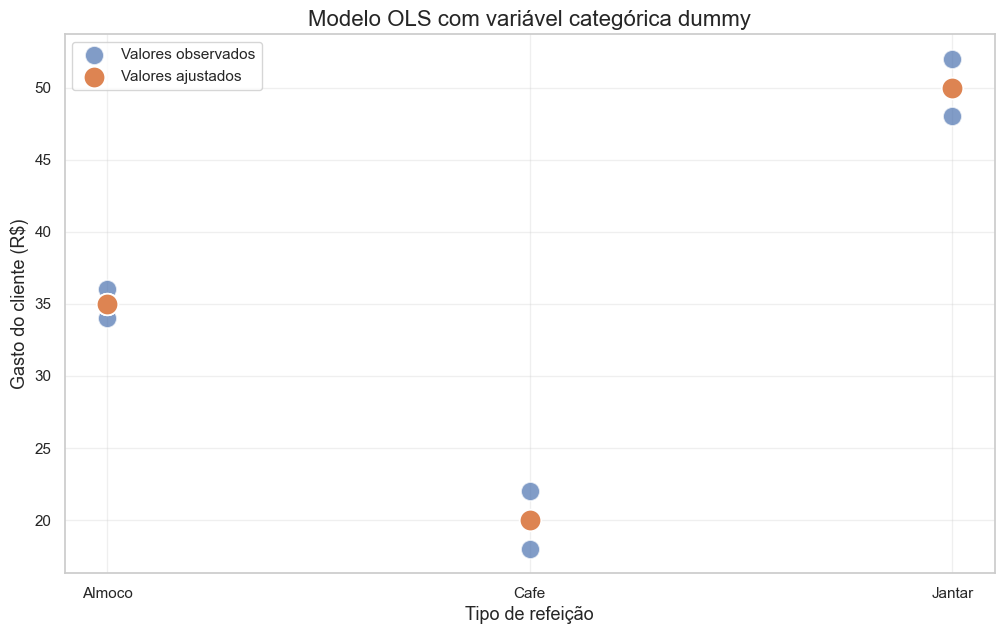

In [18]:

# ============================================================
# GRÁFICO DO MODELO COM DUMMIES
# ============================================================

plt.figure(figsize=(12, 7))

# Para facilitar o gráfico, usamos a variável numérica apenas como posição no eixo X.
# Ela não entra no modelo correto.
sns.scatterplot(
    data=df_refeicoes_dummies,
    x="refeicao_numerica",
    y="gasto",
    s=180,
    alpha=0.7,
    label="Valores observados"
)

sns.scatterplot(
    data=df_refeicoes_dummies,
    x="refeicao_numerica",
    y="fitted",
    s=240,
    label="Valores ajustados"
)

plt.title("Modelo OLS com variável categórica dummy", fontsize=16)
plt.xlabel("Tipo de refeição", fontsize=13)
plt.ylabel("Gasto do cliente (R$)", fontsize=13)

plt.xticks(
    ticks=mapeamento["refeicao_numerica"],
    labels=mapeamento["refeicao"]
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()



# 13. Resumo conceitual

| Elemento | Interpretação |
|---|---|
| Categoria de referência | Grupo base da comparação |
| Intercepto \(\alpha\) | Média de \(Y\) na categoria de referência |
| Dummy = 0 | A observação não pertence àquela categoria |
| Dummy = 1 | A observação pertence àquela categoria |
| Coeficiente da dummy \(\beta\) | Diferença média em relação à categoria de referência |
| \(k\) categorias com intercepto | Usamos \(k-1\) dummies |

## Principal cuidado

Variáveis categóricas não devem ser tratadas como números contínuos.

A dummização evita a **ponderação arbitrária** e permite interpretar corretamente as diferenças médias entre os grupos.



# 14. Texto adaptado para blog

Quando uma variável explicativa é qualitativa, como o tipo de refeição, não é adequado convertê-la diretamente em números e utilizá-la como se fosse uma variável quantitativa. Essa prática cria uma ordenação artificial entre as categorias e pode levar a uma interpretação incorreta dos coeficientes do modelo.

A forma adequada é transformar a variável categórica em variáveis dummy. Em um modelo com intercepto, uma das categorias deve ser escolhida como referência. As demais categorias são representadas por variáveis binárias, assumindo valor 1 quando a observação pertence àquela categoria e 0 caso contrário.

Nesse tipo de modelo, o intercepto representa a média da variável resposta na categoria de referência. Já os coeficientes das dummies representam a diferença média entre cada categoria alternativa e a categoria de referência.

No exemplo, considerando `Cafe` como categoria de referência, o intercepto representa o gasto médio no Café. O coeficiente da dummy `Almoco` indica quanto o gasto médio no Almoço difere do gasto médio no Café. De forma semelhante, o coeficiente da dummy `Jantar` indica quanto o gasto médio no Jantar difere do gasto médio no Café.
